In [39]:
# importing necessary Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("all libraries loaded")

all libraries loaded


In [40]:
# load the datasets
Races= pd.read_csv("data/races.csv")
Drivers= pd.read_csv("data/drivers.csv")
Results= pd.read_csv("data/Results.csv")
Constructors= pd.read_csv("data/constructors.csv")
Driver_Standings= pd.read_csv("data/driver_standings.csv")

# Check dataset Dimensions
print("Races shape:", Races.shape)
print("Drivers shape:", Drivers.shape)
print("Results shape:", Results.shape)
print("Constructors shape:", Constructors.shape)
print("Driver_Standings shape:", Driver_Standings.shape)




Races shape: (1125, 18)
Drivers shape: (861, 9)
Results shape: (26759, 18)
Constructors shape: (212, 5)
Driver_Standings shape: (34863, 7)


In [41]:
# Look at the first 5 rows of each dataset
print(Races.head())
print(Drivers.head())
print(Results.head())

   raceId  year  round  circuitId                   name        date  \
0       1  2009      1          1  Australian Grand Prix  2009-03-29   
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05   
2       3  2009      3         17     Chinese Grand Prix  2009-04-19   
3       4  2009      4          3     Bahrain Grand Prix  2009-04-26   
4       5  2009      5          4     Spanish Grand Prix  2009-05-10   

       time                                                url fp1_date  \
0  06:00:00  http://en.wikipedia.org/wiki/2009_Australian_G...       \N   
1  09:00:00  http://en.wikipedia.org/wiki/2009_Malaysian_Gr...       \N   
2  07:00:00  http://en.wikipedia.org/wiki/2009_Chinese_Gran...       \N   
3  12:00:00  http://en.wikipedia.org/wiki/2009_Bahrain_Gran...       \N   
4  12:00:00  http://en.wikipedia.org/wiki/2009_Spanish_Gran...       \N   

  fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time  \
0       \N       \N       \N       \N       

In [42]:

Races= pd.read_csv("data/races.csv",na_values=["\\N"])
Drivers= pd.read_csv("data/drivers.csv",na_values=["\\N"])
Results= pd.read_csv("data/Results.csv",na_values=["\\N"])
Driver_Standings= pd.read_csv("data/driver_standings.csv",na_values=["\\N"])

print("data reloaded with proper missing values!")



data reloaded with proper missing values!


In [43]:

# Checking for missing values in each dataset
print("Missing values in Races set:",Races.isnull().sum())
print("\nMissing values in Drivers set:\n",Drivers.isnull().sum())
print("\nMissing values in Results set\n",Results.isnull().sum())

Missing values in Races set: raceId            0
year              0
round             0
circuitId         0
name              0
date              0
time            731
url               0
fp1_date       1035
fp1_time       1057
fp2_date       1035
fp2_time       1057
fp3_date       1053
fp3_time       1072
quali_date     1035
quali_time     1057
sprint_date    1107
sprint_time    1110
dtype: int64

Missing values in Drivers set:
 driverId         0
driverRef        0
number         802
code           757
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64

Missing values in Results set
 resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507

In [44]:

# Dropping irrelevent columns

Races=Races.drop(columns=["fp1_date","fp1_time",
                          "fp2_date","fp2_time",
                          "fp3_date","fp3_time",
                          "quali_date","quali_time",
                          "sprint_date","sprint_time" ])


# handling missing values

Races["time"]=Races["time"].fillna("00:00:00")

Drivers["number"]=Drivers["number"].fillna("N/A")
Drivers["code"]=Drivers["code"].fillna("N/A")

Results["number"]=Results["number"].fillna(0)
Results["position"]=Results["position"].fillna(0)


# Verifying if missing values still exist

print("\nRaces set:\n",Races.isnull().sum(),"\nMissing values\n")
print("\nDrivers set:\n",Drivers.isnull().sum(),"\nMissing values\n")
print( "\nResults set:\n",Results.isnull().sum(),"\nMissing values\n")


Races set:
 raceId       0
year         0
round        0
circuitId    0
name         0
date         0
time         0
url          0
dtype: int64 
Missing values


Drivers set:
 driverId       0
driverRef      0
number         0
code           0
forename       0
surname        0
dob            0
nationality    0
url            0
dtype: int64 
Missing values


Results set:
 resultId               0
raceId                 0
driverId               0
constructorId          0
number                 0
grid                   0
position               0
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64 
Missing values



In [45]:
# Fixing inconsistent datatypes

Races["date"]=pd.to_datetime(Races["date"])

Races["year"]=Races["year"].astype(int)
Races["round"]=Races["round"].astype(int)

Drivers["dob"]=pd.to_datetime(Drivers["dob"])

# check duplicate values
print("duplicate values in Races:")
print(Races.duplicated().sum())

print("duplicate values in Drivers:")
print(Drivers.duplicated().sum())
print("duplicate values in Results:")
print(Results.duplicated().sum())

# there are no duplicate values


duplicate values in Races:
0
duplicate values in Drivers:
0
duplicate values in Results:
0


In [46]:

# Check dataset Dimensions
print("Races shape:", Races.shape)
print("Drivers shape:", Drivers.shape)
print("Results shape:", Results.shape)
print("Constructors shape:", Constructors.shape)
print("Driver_Standings shape:", Driver_Standings.shape)

# Basic Information and Statistics
print("Races set info:")
print(Races.info())

print("Drivers set info:")
print(Drivers.info())

print("Results set info:")
print(Results.info())

# Describing data
print(Results["grid"].describe())


Races shape: (1125, 8)
Drivers shape: (861, 9)
Results shape: (26759, 18)
Constructors shape: (212, 5)
Driver_Standings shape: (34863, 7)
Races set info:
<class 'pandas.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   raceId     1125 non-null   int64         
 1   year       1125 non-null   int64         
 2   round      1125 non-null   int64         
 3   circuitId  1125 non-null   int64         
 4   name       1125 non-null   str           
 5   date       1125 non-null   datetime64[us]
 6   time       1125 non-null   str           
 7   url        1125 non-null   str           
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 70.4 KB
None
Drivers set info:
<class 'pandas.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 

In [47]:
print("=== F1 DATASET OVERVIEW ===")

print(f"Total Seasons: {Races["year"].nunique()}")
print(f"First Season: {Races["year"].min()}")
print(f"Latest Season: {Races["year"].max()}")
print(f"Total Races: {len(Races)}")
print(f"Total Drivers: {len(Drivers)}")
print(f"Total Constructures: {len(Constructors)}")
print(f"Total Race Results: {len(Results)}")

=== F1 DATASET OVERVIEW ===
Total Seasons: 75
First Season: 1950
Latest Season: 2024
Total Races: 1125
Total Drivers: 861
Total Constructures: 212
Total Race Results: 26759


In [48]:
print("=== RACES ANALYSIS ===")

race_per_year= Races.groupby("year").size()
print(race_per_year)

print(f"Most races in a year: {race_per_year.max()} ({race_per_year.idxmax()})")
print(f"Least races in a year: {race_per_year.min()} {(race_per_year.idxmin())}")
print(f"Average races in a year: {round(race_per_year.mean(), 1)}")

=== RACES ANALYSIS ===
year
1950     7
1951     8
1952     8
1953     9
1954     9
        ..
2020    17
2021    22
2022    22
2023    22
2024    24
Length: 75, dtype: int64
Most races in a year: 24 (2024)
Least races in a year: 7 1950
Average races in a year: 15.0


In [49]:
print("=== TOP 10 DRIVERS BY WINS ===")

driver_wins= Results[Results["position"]== 1]

driver_wins=driver_wins.merge(Drivers[["driverId","forename","surname"]],on="driverId")

driver_wins["fullname"]= driver_wins["forename"]+ "" + driver_wins["surname"]

print(driver_wins["fullname"].value_counts().head(10))

=== TOP 10 DRIVERS BY WINS ===
fullname
LewisHamilton        105
MichaelSchumacher     91
MaxVerstappen         63
SebastianVettel       53
AlainProst            51
AyrtonSenna           41
FernandoAlonso        32
NigelMansell          31
JackieStewart         27
NikiLauda             25
Name: count, dtype: int64


In [50]:
print("=== TOP 10 CONSTRUCTOR BY WINS")

constructors_wins= Results[Results["position"]== 1]

constructors_wins=constructors_wins.merge(Constructors[["constructorId","name"]],on="constructorId")

print(constructors_wins["name"].value_counts().head(10))

=== TOP 10 CONSTRUCTOR BY WINS
name
Ferrari       249
McLaren       185
Mercedes      129
Red Bull      122
Williams      114
Team Lotus     45
Renault        35
Benetton       27
Brabham        23
Tyrrell        23
Name: count, dtype: int64


In [51]:
print("=== DRIVER NATIONALITIES ===")

print(f"Total Nationalities: {Drivers["nationality"].nunique()}")
print("\nTop 10:")
print(Drivers["nationality"].value_counts().head(10))

=== DRIVER NATIONALITIES ===
Total Nationalities: 43

Top 10:
nationality
British          166
American         158
Italian           99
French            73
German            50
Brazilian         32
Argentine         24
Swiss             23
Belgian           23
South African     23
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10060\880616358.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x= race_per_year.index,


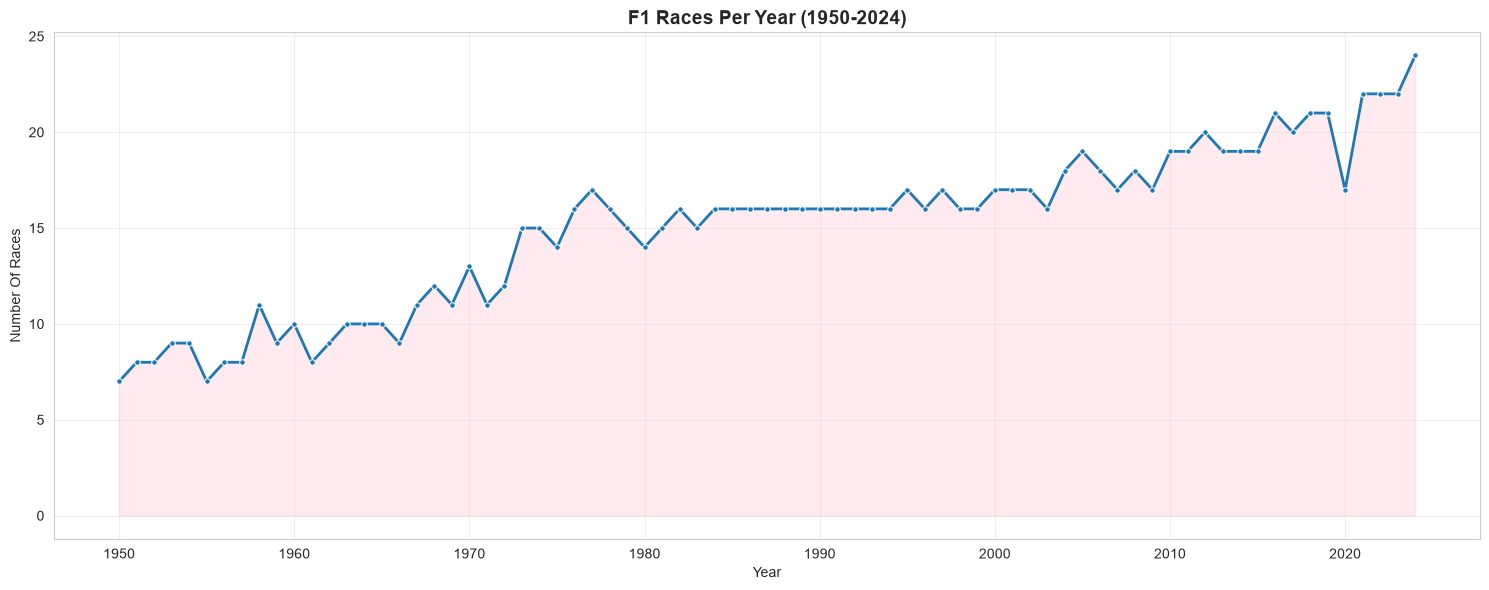

In [52]:
# Chart 1- Races per year (line chart)

plt.figure(figsize=(15,6))
sns.lineplot(x= race_per_year.index,
             y= race_per_year.values,
             palette="mako",
             linewidth=2,
             marker="o",
             markersize=4)

plt.fill_between(race_per_year.index,
                 race_per_year.values,
                 alpha=0.3,
                 color="pink")

plt.title("F1 Races Per Year (1950-2024)",
          fontsize=14,
          fontweight="bold"
          )
plt.xlabel("Year",fontsize=10)
plt.ylabel("Number Of Races",fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10060\2621530258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_drivers.values,


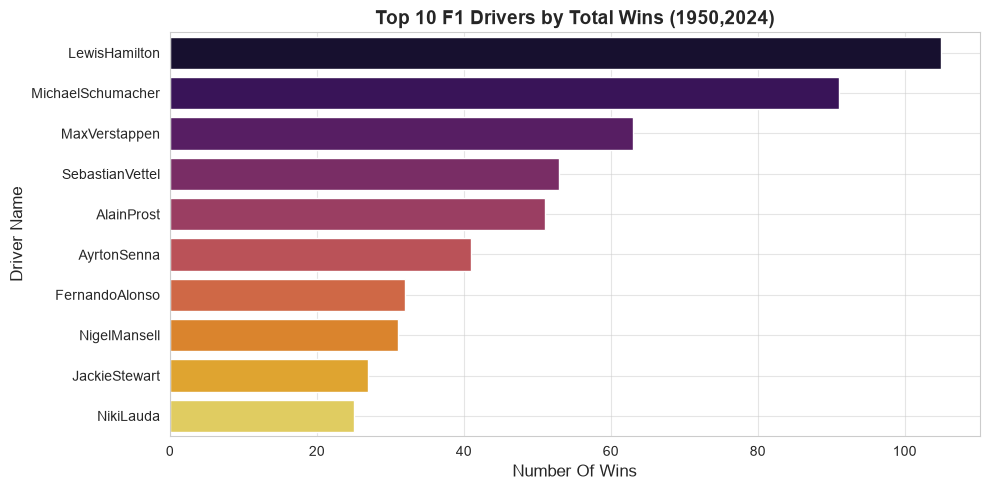

In [53]:
# Saving top 10 calculation in a variable
top_10_drivers=driver_wins["fullname"].value_counts().head(10)

# Chart 2- Top 10 Drivers By wins
plt.figure(figsize=(10,5))

sns.set_style("whitegrid")

sns.barplot(x=top_10_drivers.values,
            y=top_10_drivers.index,
            palette="inferno")

plt.title("Top 10 F1 Drivers by Total Wins (1950,2024)",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Number Of Wins",
           fontsize=12)
plt.ylabel("Driver Name",
           fontsize=12)

plt.grid(True,alpha=0.5)

plt.tight_layout()

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10060\347549072.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values,


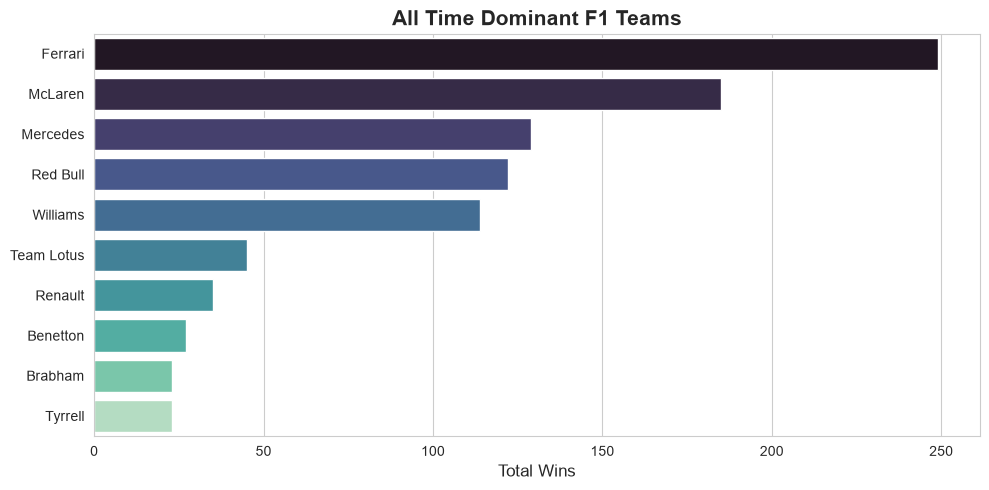

In [54]:
# Saving top 10 Constructor in variable
top_teams= constructors_wins["name"].value_counts().head(10)

# Chart 3- Top Constructor Wins
plt.figure(figsize=(10,5))

sns.barplot(x=top_teams.values,
            y=top_teams.index,
            palette="mako",
            legend=False)

plt.title("All Time Dominant F1 Teams",
          fontsize=15,
          fontweight="bold")
plt.xlabel("Total Wins",
           fontsize=12)
plt.ylabel("")

plt.tight_layout()
plt.show()

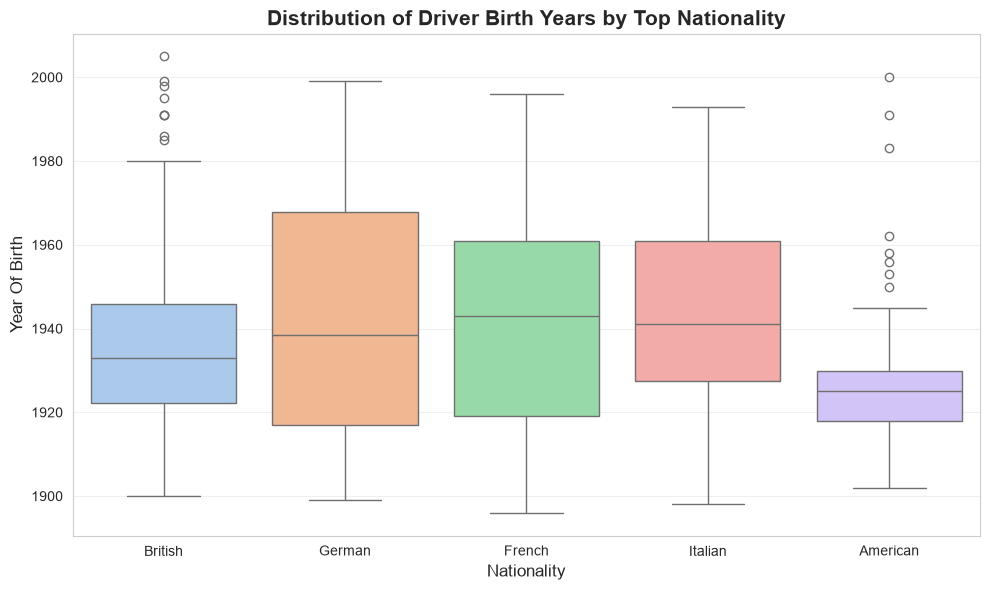

In [55]:
# Saving The Top 5 Nationalities to keep the plot clean
top_countries=Drivers["nationality"].value_counts().head(5).index
filtered_drivers=Drivers[Drivers["nationality"].isin(top_countries)]

filtered_drivers["birth_year"]=pd.to_datetime(filtered_drivers["dob"]).dt.year

# Chart 4- Distribution of Driver's Birth Years By Top Nationality
plt.figure(figsize=(10,6))

sns.boxplot(data=filtered_drivers,
            x="nationality",
            y="birth_year",
            hue="nationality",
            palette="pastel",
            legend=False)

plt.title("Distribution of Driver Birth Years by Top Nationality",
          fontsize=15,
          fontweight="bold")
plt.xlabel("Nationality",
           fontsize=12)
plt.ylabel("Year Of Birth",
           fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

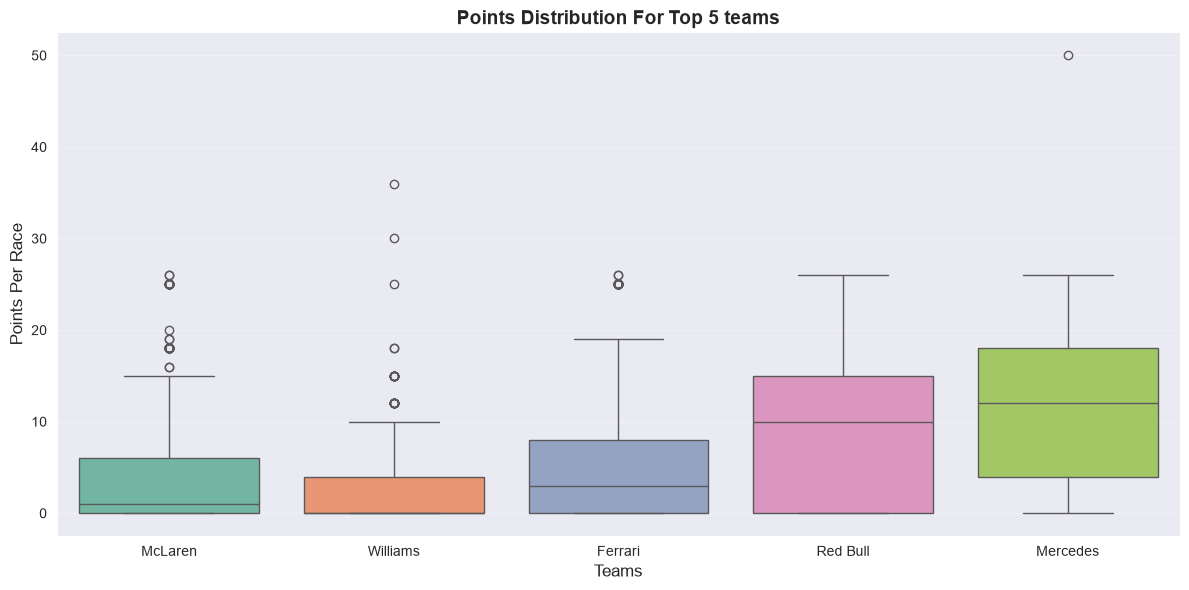

In [56]:
# Chart 5- Points Distribution For Top 3 Constructors
top5_teams= constructors_wins["name"].value_counts().head(5).index

team_results= Results.merge(
              Constructors[["constructorId","name"]],
              on="constructorId"
)
filtered_teams= team_results[team_results["name"].isin(top5_teams)]

plt.figure(figsize=(12,6))

sns.set_style("darkgrid")

sns.boxplot(data=filtered_teams,
            x="name",
            y="points",
            hue="name",
            palette="Set2",
            legend=False)

plt.title("Points Distribution For Top 5 teams",
          fontsize=14,fontweight="bold")
plt.xlabel("Teams",
           fontsize=12)
plt.ylabel("Points Per Race",
           fontsize=12)

plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

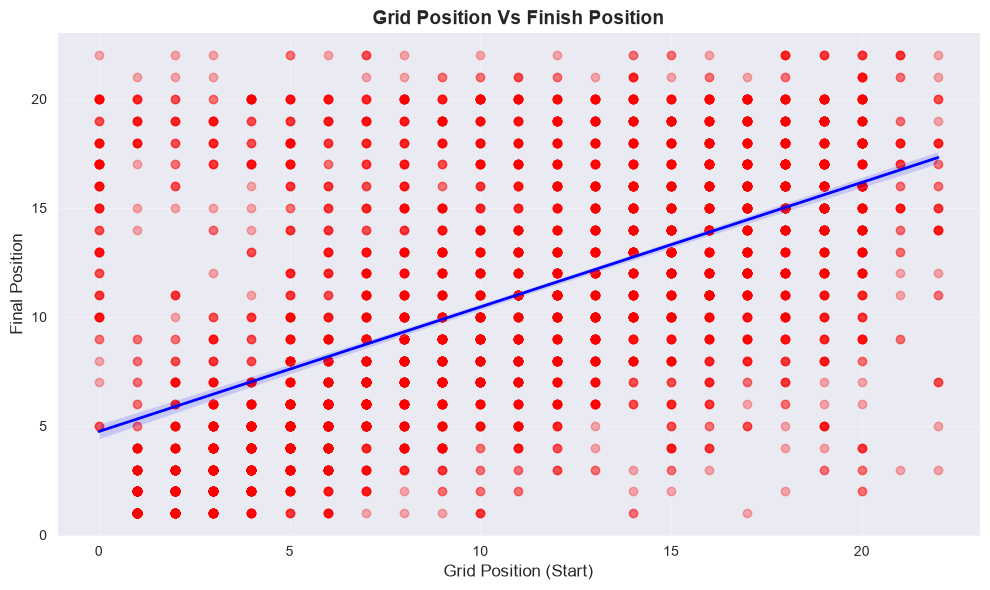

In [57]:
# Chart 6- Grid Vs Finish Positions
modern= Results[Results["raceId"]> 900]

plt.figure(figsize=(10,6))
sns.set_style("darkgrid")
sns.regplot(    data=modern,
                x="grid",
                y="positionOrder",
                scatter_kws={"color":"red","alpha":0.3},
                line_kws={"color":"blue","linewidth":2},
                )

plt.title("Grid Position Vs Finish Position",
          fontsize=14,fontweight="bold")
plt.xlabel("Grid Position (Start)",
           fontsize=12)
plt.ylabel("Final Position",
           fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10060\1691543984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_nat.values,


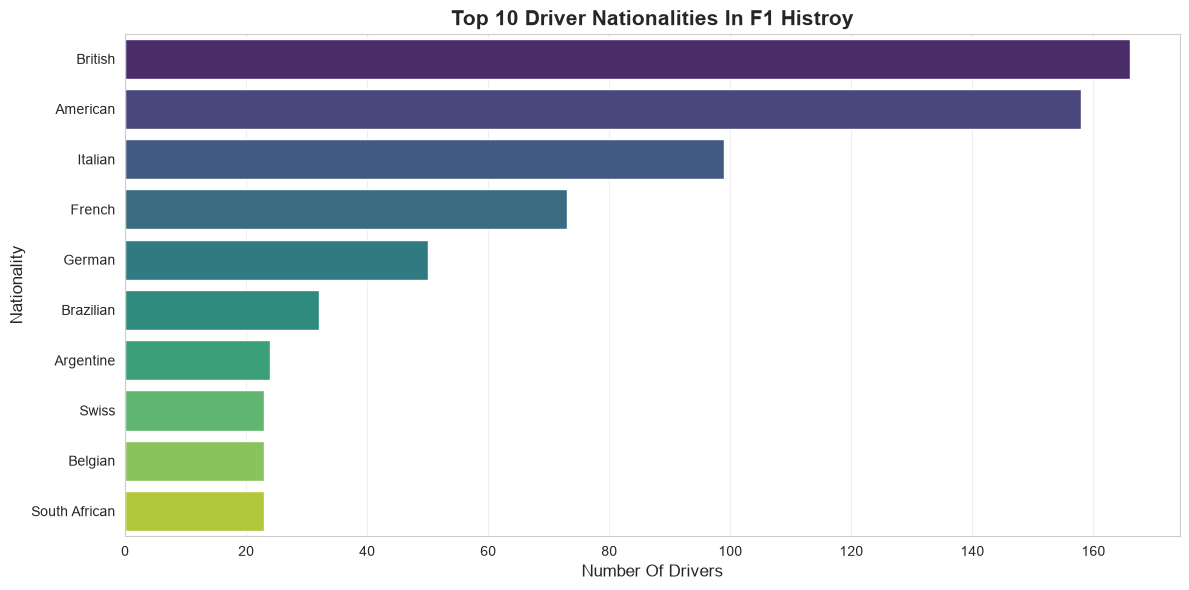

In [58]:
# Chart 7 - Top 10 Driver Nationalities 
top10_nat= Drivers["nationality"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

sns.barplot(x=top10_nat.values,
            y=top10_nat.index,
            palette="viridis")

plt.title("Top 10 Driver Nationalities In F1 Histroy",
          fontsize=15,
          fontweight="bold")
plt.xlabel("Number Of Drivers",
           fontsize=12)
plt.ylabel("Nationality",
           fontsize=12)

plt.grid(axis="x",alpha=0.3)
plt.tight_layout()
plt.show()

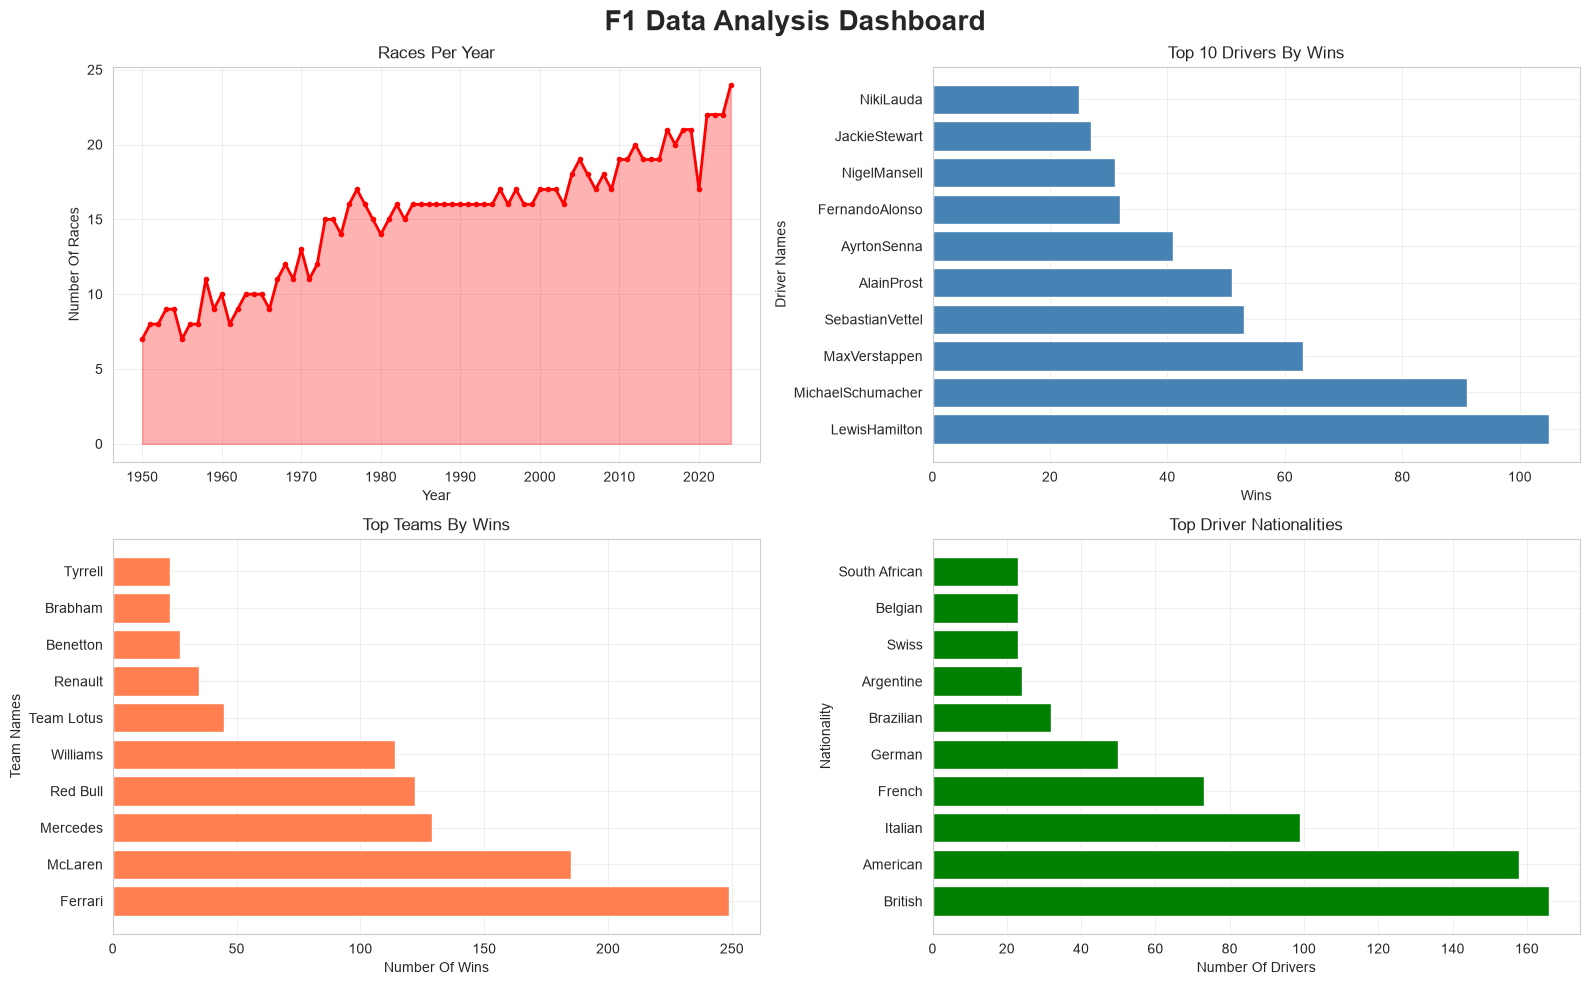

In [63]:
# Chart 8- F1 Dashboard (2x2 Subplot)

fig ,axes=plt.subplots(2,2, figsize=(16,10))

fig.suptitle("F1 Data Analysis Dashboard",
             fontsize=20,
             fontweight="bold")

# Plot 1 - Races per year (top left)
axes[0,0].plot(race_per_year.index,
               race_per_year.values,
               color="red",
               linewidth=2,
               marker="o",
               markersize=3)
axes[0,0].fill_between(race_per_year.index,
                      race_per_year.values,
                      color="red",
                      alpha=0.3)
axes[0,0].set_title("Races Per Year",
                   fontsize=12)
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Number Of Races")
axes[0,0].grid(True,alpha=0.3)

# Plot 2- Top 10 Drivers (top right)
axes[0,1].barh(top_10_drivers.index,
               top_10_drivers.values,
               color="steelblue")
axes[0,1].set_title("Top 10 Drivers By Wins",
                   fontsize=12)
axes[0,1].set_xlabel("Wins")
axes[0,1].set_ylabel("Driver Names")
axes[0,1].grid(True,alpha=0.3)

# Plot 3- Constructor Wins(bottom left)
axes[1,0].barh(top_teams.index,
               top_teams.values,
               color="coral")
axes[1,0].set_title("Top Teams By Wins",
                   fontsize=12)
axes[1,0].set_xlabel("Number Of Wins")
axes[1,0].set_ylabel("Team Names")
axes[1,0].grid(True,alpha=0.3)

# Plot 4- Nationalities (bottom right)
axes[1,1].barh(top10_nat.index,
               top10_nat.values,
               color="green")
axes[1,1].set_title("Top Driver Nationalities",
                   fontsize=12)
axes[1,1].set_xlabel("Number Of Drivers")
axes[1,1].set_ylabel("Nationality")
axes[1,1].grid(True,alpha=0.3)


plt.tight_layout()
plt.show()


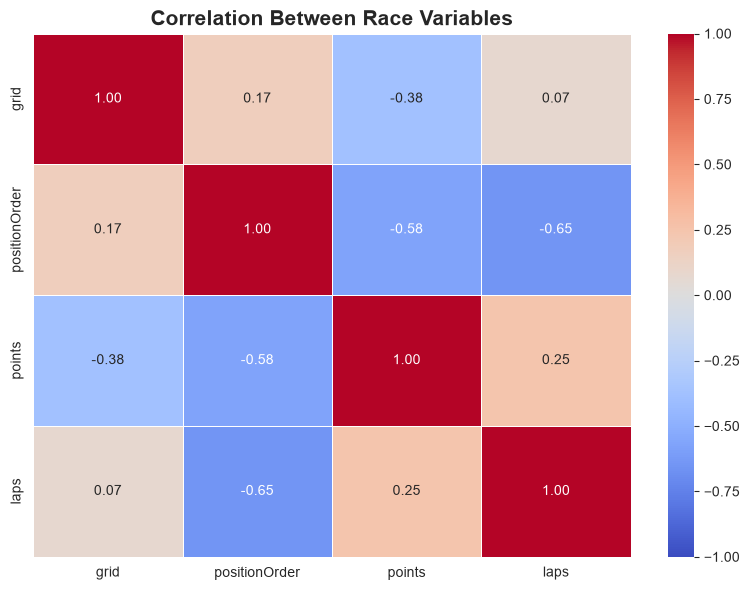

In [64]:
# Chart 9- Correlation HeatMap
numeric_cols= Results[["grid","positionOrder","points","laps"]].copy()

plt.figure(figsize=(8,6))

sns.heatmap(numeric_cols.corr() #shows correlation between columns
            annot=True,  #shows the numbers inside column
            cmap="coolwarm", #controls colors
            fmt=".2f", #how numbers are displayed
            linewidths=0.5,
            vmin=-1,
            vmax=1)

plt.title("Correlation Between Race Variables",
          fontsize=15,
          fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
print("""
╔══════════════════════════════════════════════════╗
║         F1 DATA ANALYSIS - KEY INSIGHTS          ║
╚══════════════════════════════════════════════════╝

📅 HISTORICAL GROWTH
- F1 has grown from just 7 races in 1950 to 24 races in 2024
- The sport has expanded consistently over 75 seasons
- Average of 15 races per season across all years

🏆 DRIVER DOMINANCE
- Lewis Hamilton leads all time with 105 wins
- Michael Schumacher follows with 91 wins
- Max Verstappen at 63 wins is the most dominant active driver
- Top 3 drivers account for over 25% of all F1 wins

🏗️ CONSTRUCTOR DOMINANCE
- Ferrari is the most successful team with 249 wins
- Ferrari has nearly double McLaren's wins (185)
- Top 5 teams (Ferrari, McLaren, Mercedes, Red Bull, Williams)
  account for majority of all race wins

🌍 DRIVER NATIONALITIES
- 43 different nationalities have competed in F1
- British drivers dominate with 166 drivers
- Americans follow with 158 drivers
- Shows F1's truly global reach

🎯 RACE PERFORMANCE
- Starting position strongly correlates with finish position
- Grid position 1-3 gives significant advantage
- Points and laps completed are highly correlated
- Mercedes and Red Bull show most consistent points scoring
""")


╔══════════════════════════════════════════════════╗
║         F1 DATA ANALYSIS - KEY INSIGHTS          ║
╚══════════════════════════════════════════════════╝

📅 HISTORICAL GROWTH
- F1 has grown from just 7 races in 1950 to 24 races in 2024
- The sport has expanded consistently over 75 seasons
- Average of 15 races per season across all years

🏆 DRIVER DOMINANCE
- Lewis Hamilton leads all time with 105 wins
- Michael Schumacher follows with 91 wins
- Max Verstappen at 63 wins is the most dominant active driver
- Top 3 drivers account for over 25% of all F1 wins

🏗️ CONSTRUCTOR DOMINANCE
- Ferrari is the most successful team with 249 wins
- Ferrari has nearly double McLaren's wins (185)
- Top 5 teams (Ferrari, McLaren, Mercedes, Red Bull, Williams)
  account for majority of all race wins

🌍 DRIVER NATIONALITIES
- 43 different nationalities have competed in F1
- British drivers dominate with 166 drivers
- Americans follow with 158 drivers
- Shows F1's truly global reach

🎯 RACE PERFORMA